# ResNet: спектральный анализ, погрешности и контроль downsampling

In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft as fft
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = "../imagenet"
SAVE_PATH = "zero/"
FIG_PATH = os.path.join(SAVE_PATH, "compare")
TABLE_PATH = os.path.join(SAVE_PATH, "tables")
SPECTRA_PATH = os.path.join(SAVE_PATH, "spectra_npz")

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

LOW_THRESH = 0.15
HIGH_THRESH = 0.50

# Если нужен глобальный масштаб как у layer1 ResNet при новой методике Rmax=min(H,W)/2:
# для входа 224x224 у ResNet layer1 обычно 56x56, значит Rmax=28 и длина кривой 29.
RESNET_LAYER1_REF_LEN = 29

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(SPECTRA_PATH, exist_ok=True)

print("DEVICE:", DEVICE)
print("SAVE_PATH:", SAVE_PATH)

from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import resnet34, ResNet34_Weights
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import resnet101, ResNet101_Weights

DEVICE: cpu
SAVE_PATH: zero/


## Функции

In [ ]:
# -------------------------------
# 2. Reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -------------------------------
# 3. ImageNet DataLoader
# -------------------------------
def get_imagenet_val_loader(data_dir, batch_size, num_workers):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ])
    val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return val_loader

# -------------------------------
# 4. Spectral Analysis Functions
# -------------------------------
def compute_fft_power_per_image(feat):
    """
    feat: torch.Tensor [B, C, H, W]
    Возвращает power: [B, H, W].
    Усредняем по каналам, но не по батчу — это нужно для погрешностей.
    """
    feat = feat.float()
    feat = feat - feat.mean(dim=(-2, -1), keepdim=True)
    F2 = fft.fft2(feat, norm="ortho")
    F2_shift = fft.fftshift(F2, dim=(-2, -1))
    power = torch.abs(F2_shift) ** 2
    power = power.mean(dim=1)  # [B, H, W]
    return power.detach().cpu()


def radial_profiles(power_2d_batch):
    """
    Считает два профиля для каждого изображения:
    1) radial_mean_norm — радиальная средняя мощность, используется для графиков.
    2) radial_energy_norm — суммарная энергия кольца, используется для метрик.

    Важно: доля энергии должна считаться по radial_sum, а не по radial_mean,
    потому что дальние кольца содержат больше частотных точек.
    """
    power_np = power_2d_batch.numpy()
    B, H, W = power_np.shape

    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    # Единое определение Rmax: круг Найквиста внутри частотной плоскости.
    r_max = min(H, W) // 2
    valid = R <= r_max
    R_int = np.floor(R).astype(np.int32)
    R_flat = R_int[valid].reshape(-1)

    mean_curves = []
    energy_curves = []

    for b in range(B):
        values = power_np[b][valid].reshape(-1)
        radial_sum = np.bincount(R_flat, weights=values, minlength=r_max + 1).astype(np.float64)
        radial_count = np.bincount(R_flat, minlength=r_max + 1).astype(np.float64)
        radial_count[radial_count == 0] = 1.0

        radial_mean = radial_sum / radial_count

        # Для графиков: средняя мощность по кольцу. Нормируем на сумму, затем при отрисовке — на максимум.
        if radial_mean.sum() > 0:
            radial_mean_norm = radial_mean / radial_mean.sum()
        else:
            radial_mean_norm = radial_mean

        # Для метрик: суммарная энергия кольца. Это корректная доля энергии.
        if radial_sum.sum() > 0:
            radial_energy_norm = radial_sum / radial_sum.sum()
        else:
            radial_energy_norm = radial_sum

        mean_curves.append(radial_mean_norm)
        energy_curves.append(radial_energy_norm)

    rho = np.arange(r_max + 1) / max(1, r_max)
    return np.stack(mean_curves, axis=0), np.stack(energy_curves, axis=0), rho


def align_curves(curves):
    min_len = min(c.shape[-1] for c in curves)
    return np.concatenate([c[..., :min_len] for c in curves], axis=0)


def collect_all_spectra(model, loader, device, max_batches, image_plot=False):
    """
    Собирает все спектры, а не только среднюю кривую.
    Возвращает по каждому слою:
    - curves_mean: радиальная средняя мощность для графиков [N, R]
    - curves_energy: суммарная энергия по кольцам для метрик [N, R]
    - mean/std по curves_mean
    - energy_mean/energy_std по curves_energy
    - rho и resolution
    """
    model.eval()
    spectra = {}

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt % 30 == 13:
                print(f"batch {cnt}")
            images = images.to(device)
            _ = model(images)
            feats = model.get_features()

            for name, feat in feats.items():
                feat_bchw = model.feature_to_bchw(name, feat)
                power = compute_fft_power_per_image(feat_bchw)
                mean_curves, energy_curves, rho = radial_profiles(power)

                if name not in spectra:
                    spectra[name] = {
                        "curves_mean": [],
                        "curves_energy": [],
                        "rho": rho,
                        "resolution": feat_bchw.shape[-2:]
                    }
                spectra[name]["curves_mean"].append(mean_curves)
                spectra[name]["curves_energy"].append(energy_curves)

            if cnt >= max_batches:
                break

    stats = {}
    for name, data in spectra.items():
        curves_mean = align_curves(data["curves_mean"])
        curves_energy = align_curves(data["curves_energy"])
        rho = data["rho"][:curves_mean.shape[1]]

        stats[name] = {
            "curves_mean": curves_mean,
            "curves_energy": curves_energy,
            "mean": curves_mean.mean(axis=0),
            "std": curves_mean.std(axis=0, ddof=1),
            "energy_mean": curves_energy.mean(axis=0),
            "energy_std": curves_energy.std(axis=0, ddof=1),
            "rho": rho,
            "resolution": data["resolution"],
            "n": curves_mean.shape[0]
        }
    return stats

def save_spectra_npz(stats, save_path):
    arrays = {}
    layers = list(stats.keys())
    arrays["layers"] = np.array(layers, dtype=object)
    for i, layer in enumerate(layers):
        d = stats[layer]
        arrays[f"curves_mean_{i}"] = d["curves_mean"]
        arrays[f"curves_energy_{i}"] = d["curves_energy"]
        arrays[f"mean_{i}"] = d["mean"]
        arrays[f"std_{i}"] = d["std"]
        arrays[f"energy_mean_{i}"] = d["energy_mean"]
        arrays[f"energy_std_{i}"] = d["energy_std"]
        arrays[f"rho_{i}"] = d["rho"]
        arrays[f"resolution_{i}"] = np.array(d["resolution"])
        arrays[f"n_{i}"] = np.array(d["n"])
    np.savez_compressed(save_path, **arrays)
    print("saved:", save_path)


def load_spectra_npz(path):
    data = np.load(path, allow_pickle=True)
    layers = list(data["layers"])
    stats = {}
    for i, layer in enumerate(layers):
        stats[layer] = {
            "curves_mean": data[f"curves_mean_{i}"],
            "curves_energy": data[f"curves_energy_{i}"],
            "mean": data[f"mean_{i}"],
            "std": data[f"std_{i}"],
            "energy_mean": data[f"energy_mean_{i}"],
            "energy_std": data[f"energy_std_{i}"],
            "rho": data[f"rho_{i}"],
            "resolution": tuple(data[f"resolution_{i}"].tolist()),
            "n": int(data[f"n_{i}"])
        }
    return stats

# -------------------------------
# 5. Hooked Model
# -------------------------------
class HookedResNet(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.features = {}

        def hook_fn(name):
            def fn(module, input, output):
                self.features[name] = output.detach()
            return fn

        self.model.layer1.register_forward_hook(hook_fn("layer1"))
        self.model.layer2.register_forward_hook(hook_fn("layer2"))
        self.model.layer3.register_forward_hook(hook_fn("layer3"))
        self.model.layer4.register_forward_hook(hook_fn("layer4"))

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

    def feature_to_bchw(self, name, feat):
        return feat

# Для внутристадийного контроля, например ResNet50 layer3.
class HookedResNetBlocks(nn.Module):
    def __init__(self, model, layer_name="layer3"):
        super().__init__()
        self.model = model
        self.features = {}
        layer = getattr(self.model, layer_name)

        def hook_fn(name):
            def fn(module, input, output):
                self.features[name] = output.detach()
            return fn

        for idx, block in enumerate(layer):
            block.register_forward_hook(hook_fn(f"{layer_name}_block{idx}"))

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

    def feature_to_bchw(self, name, feat):
        return feat

## Функции графиков и метрик

In [ ]:
# -------------------------------
# 7. Metrics and LaTeX tables
# -------------------------------
def compute_metrics_for_layer(energy_curves, rho, freq_scale=1.0, low_thresh=LOW_THRESH, high_thresh=HIGH_THRESH):
    rows = []
    x = rho * freq_scale
    for curve in energy_curves:
        curve = curve / max(curve.sum(), 1e-12)
        centroid = float(np.sum(x * curve))
        low_frac = float(curve[x < low_thresh].sum())
        high_frac = float(curve[x > high_thresh].sum())
        rows.append({
            "centroid": centroid,
            "low_frac": low_frac,
            "high_frac": high_frac
        })
    return pd.DataFrame(rows)


def summarize_layer_metrics(df):
    return {
        "centroid_mean": df["centroid"].mean(),
        "centroid_std": df["centroid"].std(ddof=1),
        "low_frac_mean": df["low_frac"].mean(),
        "low_frac_std": df["low_frac"].std(ddof=1),
        "high_frac_mean": df["high_frac"].mean(),
        "high_frac_std": df["high_frac"].std(ddof=1),
        "n": len(df)
    }


def compute_metrics_table(stats, selected_layers, ref_layer=None, ref_len=None, architecture=""):
    if ref_len is None:
        if ref_layer is None:
            ref_layer = selected_layers[0]
        ref_len = len(stats[ref_layer]["rho"])

    rows = []
    for pos, layer in selected_layers.items():
        d = stats[layer]
        freq_scale = len(d["rho"]) / ref_len
        df = compute_metrics_for_layer(
            d["curves_energy"],
            d["rho"],
            freq_scale=freq_scale,
            low_thresh=LOW_THRESH,
            high_thresh=HIGH_THRESH
        )
        s = summarize_layer_metrics(df)
        rows.append({
            "architecture": architecture,
            "position": pos,
            "layer": layer,
            "resolution": str(d["resolution"]),
            "freq_scale": freq_scale,
            **s
        })
    return pd.DataFrame(rows)


def fmt_pm(mean, std, digits=3, percent=False):
    if percent:
        mean = mean * 100
        std = std * 100
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def make_latex_ready_table(metrics_df, model_name):
    rows = []
    for _, r in metrics_df.iterrows():
        rows.append({
            "Модель": model_name,
            "Уровень": r["position"],
            "Слой/блок": r["layer"],
            "Центроид": fmt_pm(r["centroid_mean"], r["centroid_std"], digits=3),
            "LowFrac, \\%": fmt_pm(r["low_frac_mean"], r["low_frac_std"], digits=3, percent=True),
            "HighFrac, \\%": fmt_pm(r["high_frac_mean"], r["high_frac_std"], digits=3, percent=True),
        })
    return pd.DataFrame(rows)


def save_metrics_tables(metrics_df, model_name, prefix):
    csv_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_long.csv")
    tex_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex.tex")
    pretty_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex_ready.csv")

    latex_df = make_latex_ready_table(metrics_df, model_name)
    metrics_df.to_csv(csv_path, index=False)
    latex_df.to_csv(pretty_path, index=False)

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(latex_df.to_latex(index=False, escape=False))

    print("saved:", csv_path)
    print("saved:", pretty_path)
    print("saved:", tex_path)
    return latex_df


# -------------------------------
# 8. Функции графиков с погрешностями
# -------------------------------
def _curve_for_plot(d):
    curve = d["mean"].copy()
    std = d["std"].copy()
    m = max(curve.max(), 1e-12)
    return curve / m, std / m


def plot_spectra_compare(model_name, stats, plot_layers=None, ref_res=None, save_path=None):
    # Spatial resolutions of each layer (used to scale frequency axes)
    if plot_layers is None:
        plot_layers = list(stats.keys())
    resolutions = {layer: len(stats[layer]["mean"]) for layer in plot_layers}

    if ref_res is None:
        ref_res = resolutions[plot_layers[0]]

    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    for i, layer in enumerate(plot_layers):
        curve, std = _curve_for_plot(stats[layer])
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        scale = resolutions[layer] / ref_res
        x_mapped = x * scale

        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=3)
        plt.fill_between(x_mapped,
                         np.maximum(curve - std, 0),
                         curve + std,
                         color=f"C{i}", alpha=0.1)
        step = max(1, L // 8)
        plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step],
                     fmt="none", ecolor=f"C{i}", elinewidth=1.2, capsize=3, alpha=0.8)

    plt.title(f"Спектральная энергия слоев {model_name}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


def plot_spectra_compare_in_layer(models_stats_dict, block, ref_res=None, save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    for j, (key, stats) in enumerate(models_stats_dict.items()):
        layers = list(stats.keys())
        num = len(layers)
        if block == "начального":
            layer = layers[0]
        elif block == "среднего":
            layer = layers[num // 2]
        elif block == "последнего":
            layer = layers[-1]
        else:
            raise ValueError("block должен быть: начального, среднего или последнего")

        if ref_res is None:
            local_ref = len(stats[layers[0]]["mean"])
        else:
            local_ref = ref_res

        curve, std = _curve_for_plot(stats[layer])
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        scale = L / local_ref
        x_mapped = x * scale

        marker = markers.get(key, "o")
        plt.plot(x_mapped, curve, label=f"{key}-{layer}", color=f"C{j}", linewidth=3, marker=marker, markevery=max(1, L//8))
        plt.fill_between(x_mapped, np.maximum(curve - std, 0), curve + std, color=f"C{j}", alpha=0.1)
        step = max(1, L // 8)
        plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step],
                     fmt="none", ecolor=f"C{j}", elinewidth=1.2, capsize=3, alpha=0.8)

    plt.title(f"Спектральная энергия {block} слоя", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# -------------------------------
# 9. Контрольные эксперименты
# -------------------------------
def downsample_feature(feat_bchw, target_hw, mode="avg_pool"):
    if mode == "avg_pool":
        return F.adaptive_avg_pool2d(feat_bchw, output_size=target_hw)
    if mode == "bilinear":
        return F.interpolate(feat_bchw, size=target_hw, mode="bilinear", align_corners=False)
    raise ValueError("mode должен быть avg_pool или bilinear")


def collect_downsampling_control(model, loader, device, source_layer, target_layers, max_batches, mode="avg_pool"):
    """
    source_layer искусственно уменьшается до разрешений target_layers.
    Сравнение real target_layer vs source_layer_downsampled_to_target показывает,
    какая часть эффекта объясняется одним только уменьшением разрешения.
    """
    model.eval()
    control = {}

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt % 30 == 13:
                print(f"control batch {cnt}")
            images = images.to(device)
            _ = model(images)
            feats = model.get_features()

            source_feat = model.feature_to_bchw(source_layer, feats[source_layer])

            for target_layer in target_layers:
                real_feat = model.feature_to_bchw(target_layer, feats[target_layer])
                target_hw = real_feat.shape[-2:]
                base_feat = downsample_feature(source_feat, target_hw, mode=mode)

                for kind, feat in [("real", real_feat), (f"{source_layer}_down_{mode}", base_feat)]:
                    name = f"{kind}__{target_layer}"
                    power = compute_fft_power_per_image(feat)
                    mean_curves, energy_curves, rho = radial_profiles(power)
                    if name not in control:
                        control[name] = {"curves_mean": [], "curves_energy": [], "rho": rho, "resolution": feat.shape[-2:]}
                    control[name]["curves_mean"].append(mean_curves)
                    control[name]["curves_energy"].append(energy_curves)

            if cnt >= max_batches:
                break

    stats = {}
    for name, data in control.items():
        curves_mean = align_curves(data["curves_mean"])
        curves_energy = align_curves(data["curves_energy"])
        rho = data["rho"][:curves_mean.shape[1]]
        stats[name] = {
            "curves_mean": curves_mean,
            "curves_energy": curves_energy,
            "mean": curves_mean.mean(axis=0),
            "std": curves_mean.std(axis=0, ddof=1),
            "energy_mean": curves_energy.mean(axis=0),
            "energy_std": curves_energy.std(axis=0, ddof=1),
            "rho": rho,
            "resolution": data["resolution"],
            "n": curves_mean.shape[0]
        }
    return stats


def control_metrics_table(control_stats, source_layer, target_layers, ref_len, mode="avg_pool", prefix=""):
    rows = []
    for target in target_layers:
        real_key = f"real__{target}"
        base_key = f"{source_layer}_down_{mode}__{target}"
        real = control_stats[real_key]
        base = control_stats[base_key]

        real_df = compute_metrics_for_layer(real["curves_energy"], real["rho"], freq_scale=len(real["rho"]) / ref_len)
        base_df = compute_metrics_for_layer(base["curves_energy"], base["rho"], freq_scale=len(base["rho"]) / ref_len)

        rows.append({
            "target_layer": target,
            "real_centroid": real_df["centroid"].mean(),
            "real_centroid_std": real_df["centroid"].std(ddof=1),
            "baseline_centroid": base_df["centroid"].mean(),
            "baseline_centroid_std": base_df["centroid"].std(ddof=1),
            "delta_centroid": real_df["centroid"].mean() - base_df["centroid"].mean(),
            "real_low_frac": real_df["low_frac"].mean(),
            "real_low_frac_std": real_df["low_frac"].std(ddof=1),
            "baseline_low_frac": base_df["low_frac"].mean(),
            "baseline_low_frac_std": base_df["low_frac"].std(ddof=1),
            "delta_low_frac": real_df["low_frac"].mean() - base_df["low_frac"].mean(),
        })
    df = pd.DataFrame(rows)
    if prefix:
        df.to_csv(os.path.join(TABLE_PATH, f"{prefix}_downsampling_control.csv"), index=False)
        with open(os.path.join(TABLE_PATH, f"{prefix}_downsampling_control.tex"), "w", encoding="utf-8") as f:
            f.write(df.round(3).to_latex(index=False, escape=False))
    return df


def plot_downsampling_control(control_stats, source_layer, target_layer, ref_len, model_name, mode="avg_pool", save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    keys = [(f"real__{target_layer}", f"реальный {target_layer}"),
            (f"{source_layer}_down_{mode}__{target_layer}", f"{source_layer} → размер {target_layer}")]

    for i, (k, label) in enumerate(keys):
        d = control_stats[k]
        curve = d["mean"]
        std = d["std"]
        m = max(curve.max(), 1e-12)
        curve = curve / m
        std = std / m
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        x_mapped = x * (L / ref_len)
        plt.plot(x_mapped, curve, label=label, color=f"C{i}", linewidth=3)
        plt.fill_between(x_mapped, np.maximum(curve-std, 0), curve+std, color=f"C{i}", alpha=0.1)
        step = max(1, L // 8)
        plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step], fmt="none", ecolor=f"C{i}", capsize=3)

    plt.title(f"Контроль downsampling: {model_name}, {target_layer}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

## Начало экспериментов: получение спектров ResNet

In [6]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)

resnet_models = {
    "ResNet_18": (resnet18, ResNet18_Weights.DEFAULT, "resnet18"),
    "ResNet_34": (resnet34, ResNet34_Weights.DEFAULT, "resnet34"),
    "ResNet_50": (resnet50, ResNet50_Weights.DEFAULT, "resnet50"),
    "ResNet_101": (resnet101, ResNet101_Weights.DEFAULT, "resnet101"),
}

all_resnet_stats = {}

In [ ]:
for model_key, (builder, weights, file_prefix) in resnet_models.items():
    print("\n====", model_key, "====")
    base_model = builder(weights=weights).to(DEVICE)
    model = HookedResNet(base_model).to(DEVICE)
    stats = collect_all_spectra(model, val_loader, DEVICE, MAX_BATCHES)
    all_resnet_stats[model_key] = stats
    save_spectra_npz(stats, os.path.join(SPECTRA_PATH, f"{file_prefix}_all_layers.npz"))

## Сохранённые спектры открыть

In [ ]:
# После запуска экспериментов можно открывать уже сохранённые данные так:
# stats_18 = load_spectra_npz(os.path.join(SPECTRA_PATH, "resnet18_all_layers.npz"))
# stats_34 = load_spectra_npz(os.path.join(SPECTRA_PATH, "resnet34_all_layers.npz"))
# stats_50 = load_spectra_npz(os.path.join(SPECTRA_PATH, "resnet50_all_layers.npz"))
# stats_101 = load_spectra_npz(os.path.join(SPECTRA_PATH, "resnet101_all_layers.npz"))

# all_resnet_stats = {}
# for model_key, (builder, weights, file_prefix) in resnet_models.items():
#     print("\n====", model_key, "====")
#     stats = load_spectra_npz(os.path.join(SPECTRA_PATH, f"{file_prefix}_all_layers.npz"))
#     all_resnet_stats[model_key] = stats


==== ResNet_18 ====

==== ResNet_34 ====

==== ResNet_50 ====

==== ResNet_101 ====


## Вызов построения и сохранения графиков

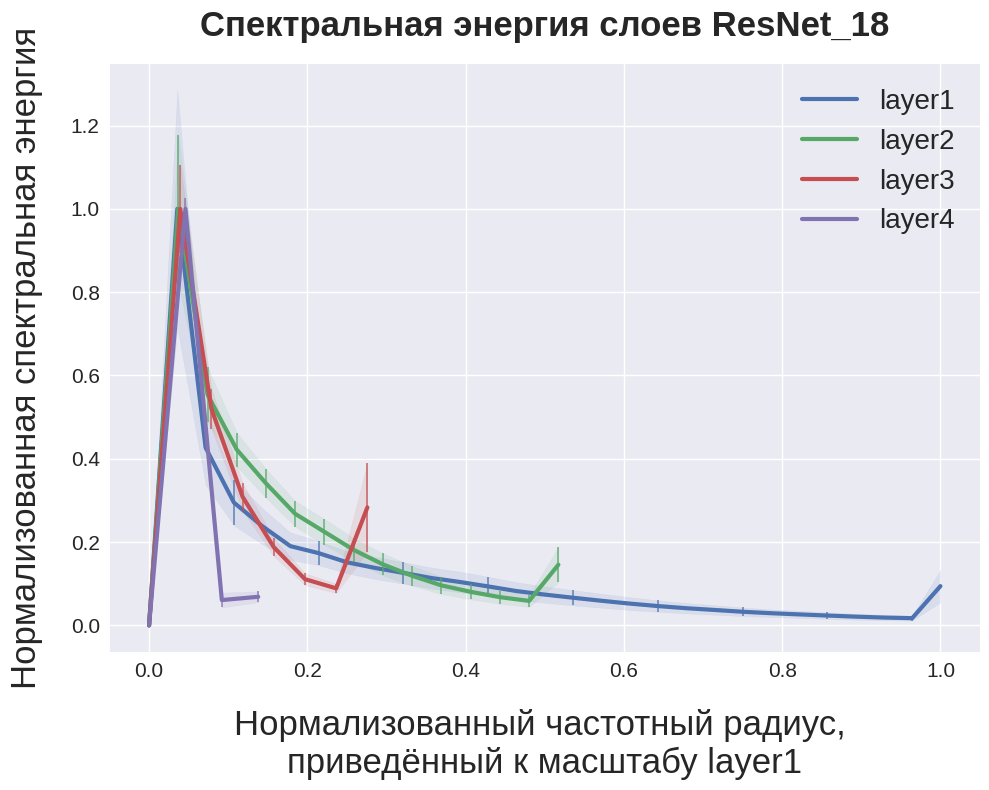

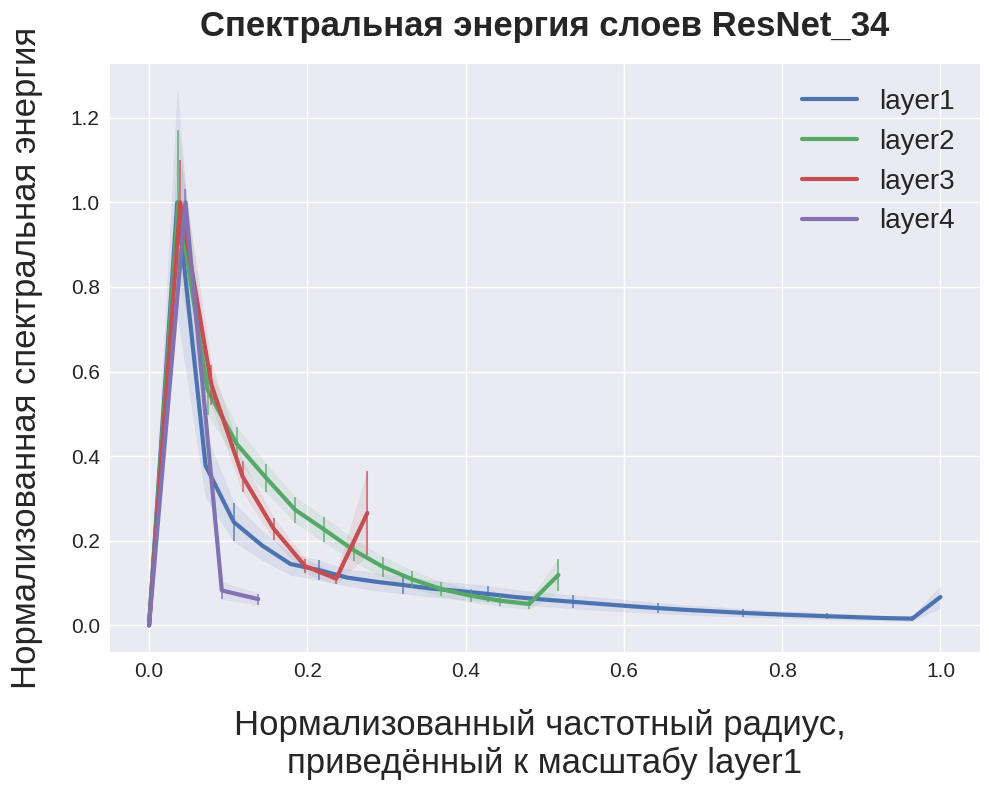

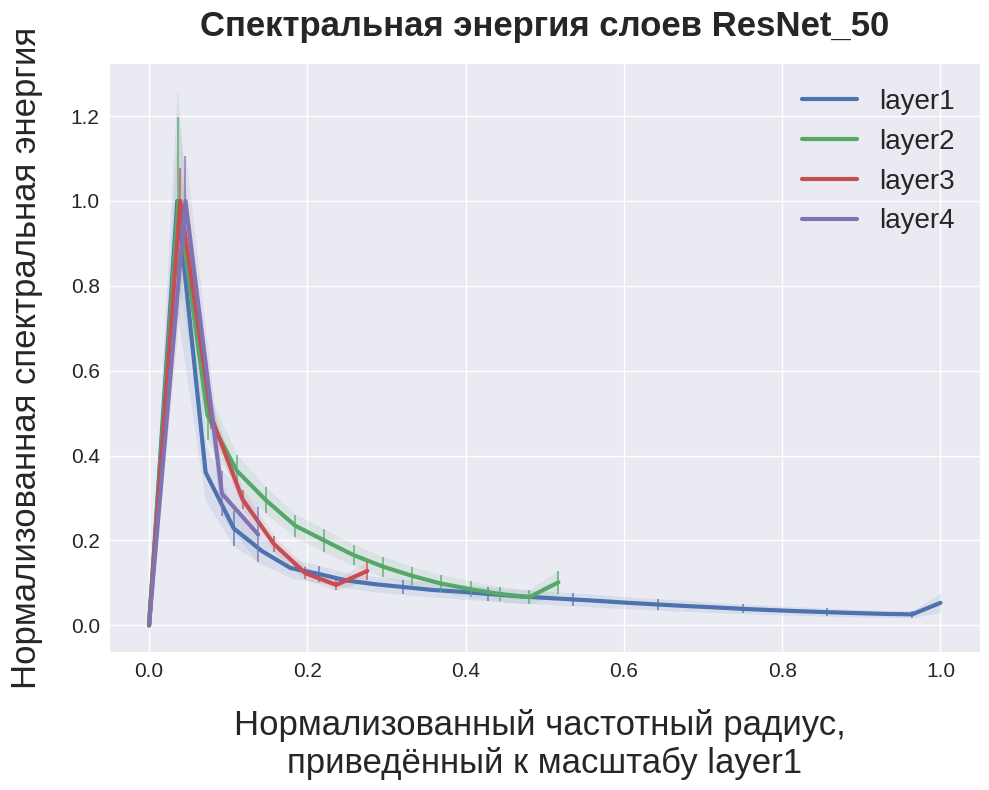

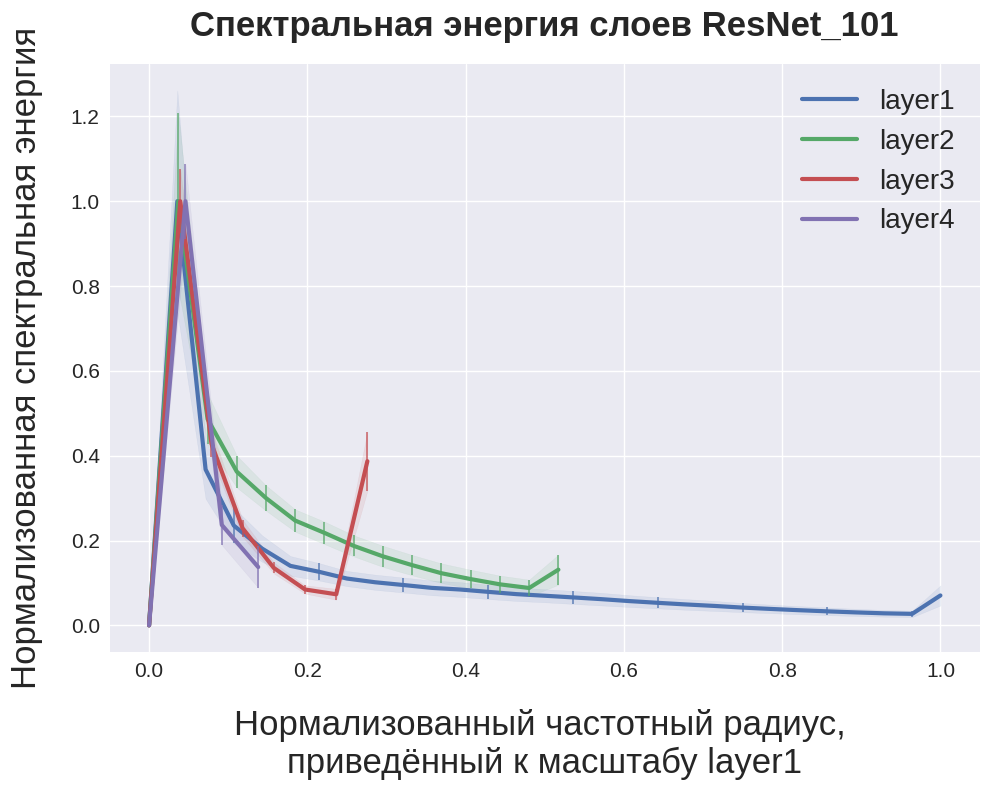

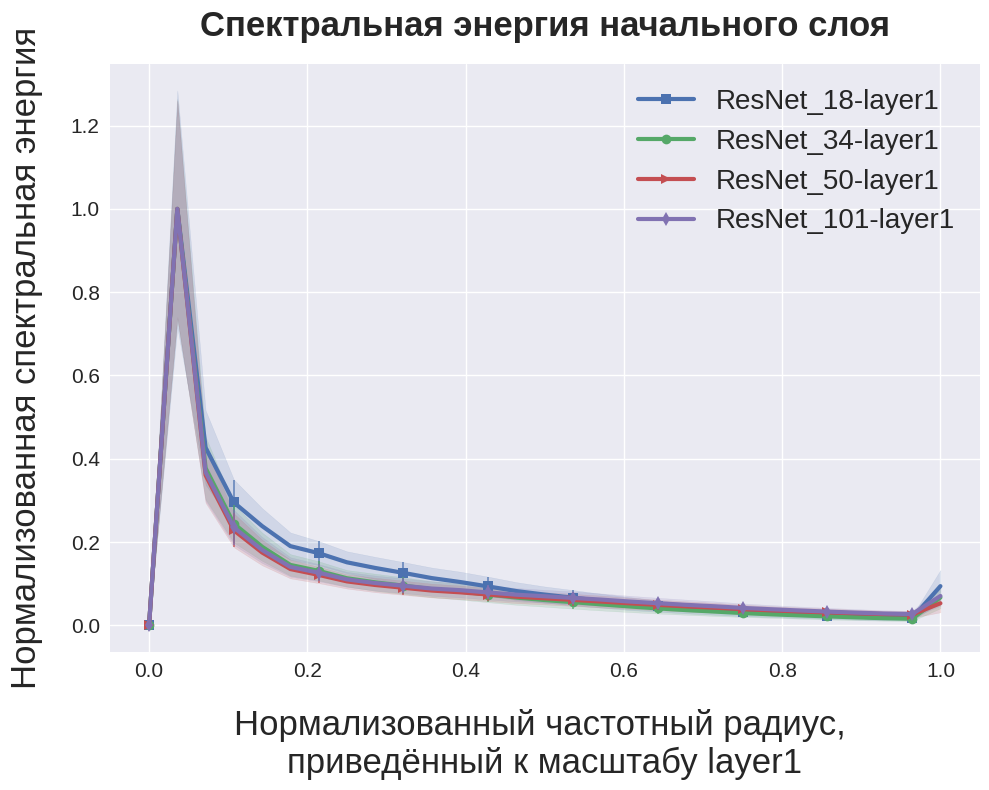

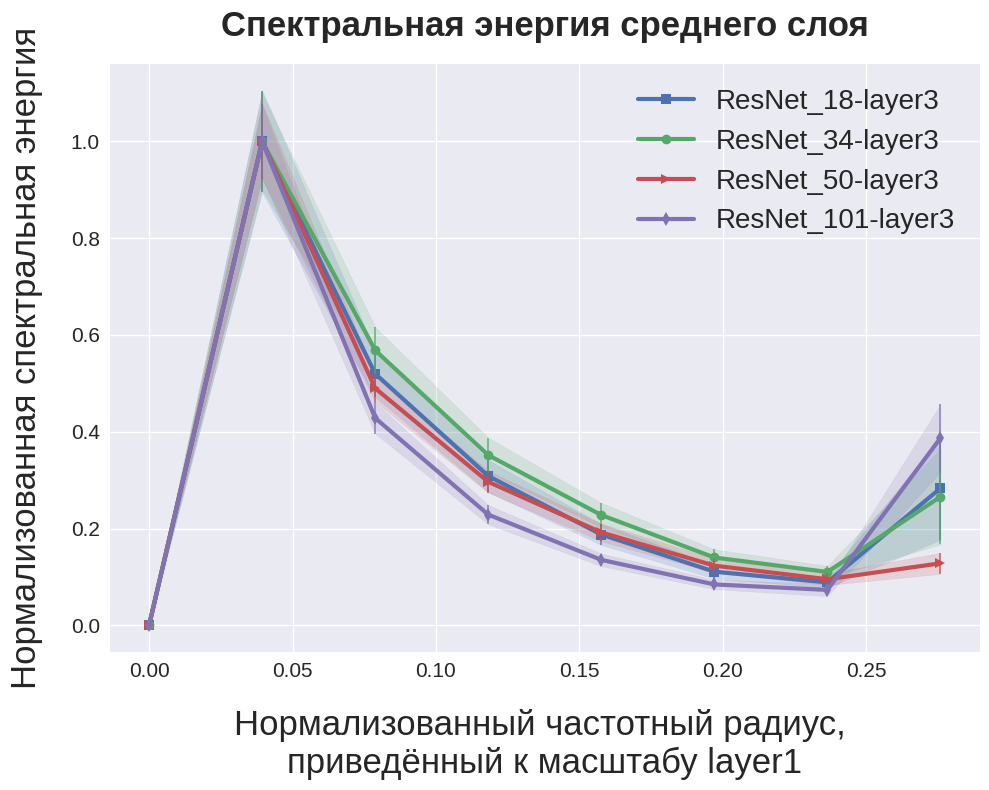

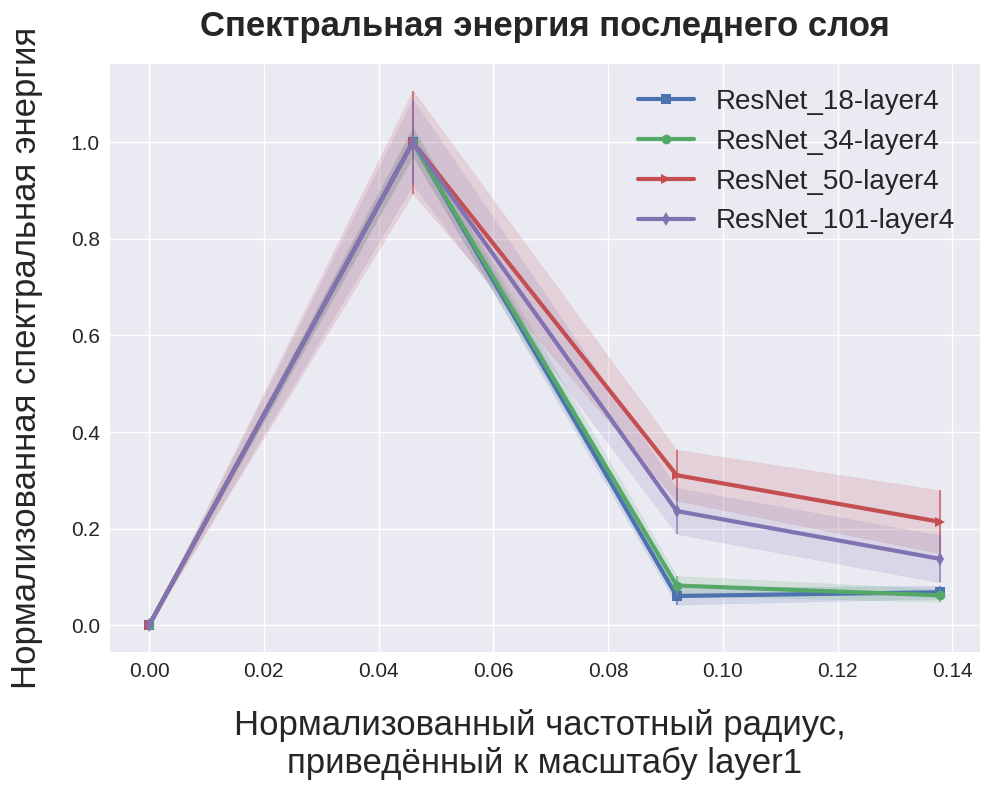

In [22]:
markers = {
    "ResNet_18": "s",
    "ResNet_34": "o",
    "ResNet_50": ">",
    "ResNet_101": "d",
}

# Для визуализации ResNet используются все 4 слоя.
for model_key, stats in all_resnet_stats.items():
    plot_spectra_compare(
        model_key,
        stats,
        plot_layers=["layer1", "layer2", "layer3", "layer4"],
        ref_res=len(stats["layer1"]["mean"]),
        save_path=os.path.join(FIG_PATH, f"{model_key}_spectra_layers.png")
    )

plot_spectra_compare_in_layer(all_resnet_stats, "начального", save_path=os.path.join(FIG_PATH, "resnet_begin_block.png"))
plot_spectra_compare_in_layer(all_resnet_stats, "среднего", save_path=os.path.join(FIG_PATH, "resnet_middle_block.png"))
plot_spectra_compare_in_layer(all_resnet_stats, "последнего", save_path=os.path.join(FIG_PATH, "resnet_last_block.png"))

## Выведение и сохранение значений метрик

In [8]:
# В таблицы идут только начальный, средний и последний уровни.
# Для ResNet средний уровень оставлен как layer2, чтобы сохранить логику старых таблиц/графиков.
selected_resnet_layers = {
    "Начальные": "layer1",
    "Средние": "layer2",
    "Глубокие": "layer4",
}

all_metrics = []
for model_key, stats in all_resnet_stats.items():
    metrics_df = compute_metrics_table(
        stats,
        selected_layers=selected_resnet_layers,
        ref_layer="layer1",
        architecture=model_key
    )
    all_metrics.append(metrics_df)
    latex_df = save_metrics_tables(metrics_df, model_key, model_key.lower())
    display(latex_df)

resnet_metrics_all = pd.concat(all_metrics, ignore_index=True)
resnet_metrics_all.to_csv(os.path.join(TABLE_PATH, "resnet_all_metrics_long.csv"), index=False)
display(resnet_metrics_all)

saved: zero/tables/resnet_18_metrics_long.csv
saved: zero/tables/resnet_18_metrics_latex_ready.csv
saved: zero/tables/resnet_18_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ResNet_18,Начальные,layer1,0.433 $\pm$ 0.037,17.616 $\pm$ 4.924,36.754 $\pm$ 5.402
1,ResNet_18,Средние,layer2,0.236 $\pm$ 0.015,34.403 $\pm$ 4.851,0.301 $\pm$ 0.108
2,ResNet_18,Глубокие,layer4,0.054 $\pm$ 0.002,100.000 $\pm$ 0.000,0.000 $\pm$ 0.000


saved: zero/tables/resnet_34_metrics_long.csv
saved: zero/tables/resnet_34_metrics_latex_ready.csv
saved: zero/tables/resnet_34_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ResNet_34,Начальные,layer1,0.441 $\pm$ 0.038,18.714 $\pm$ 5.067,39.025 $\pm$ 5.609
1,ResNet_34,Средние,layer2,0.229 $\pm$ 0.013,35.956 $\pm$ 4.477,0.255 $\pm$ 0.099
2,ResNet_34,Глубокие,layer4,0.055 $\pm$ 0.002,100.000 $\pm$ 0.000,0.000 $\pm$ 0.000


saved: zero/tables/resnet_50_metrics_long.csv
saved: zero/tables/resnet_50_metrics_latex_ready.csv
saved: zero/tables/resnet_50_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ResNet_50,Начальные,layer1,0.483 $\pm$ 0.034,16.285 $\pm$ 4.332,46.292 $\pm$ 5.090
1,ResNet_50,Средние,layer2,0.244 $\pm$ 0.015,32.853 $\pm$ 4.845,0.216 $\pm$ 0.054
2,ResNet_50,Глубокие,layer4,0.068 $\pm$ 0.004,100.000 $\pm$ 0.000,0.000 $\pm$ 0.000


saved: zero/tables/resnet_101_metrics_long.csv
saved: zero/tables/resnet_101_metrics_latex_ready.csv
saved: zero/tables/resnet_101_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ResNet_101,Начальные,layer1,0.488 $\pm$ 0.033,15.625 $\pm$ 4.120,47.006 $\pm$ 4.909
1,ResNet_101,Средние,layer2,0.258 $\pm$ 0.015,29.074 $\pm$ 4.439,0.249 $\pm$ 0.066
2,ResNet_101,Глубокие,layer4,0.064 $\pm$ 0.004,100.000 $\pm$ 0.000,0.000 $\pm$ 0.000


,architecture,position,layer,resolution,freq_scale,centroid_mean,centroid_std,low_frac_mean,low_frac_std,high_frac_mean,high_frac_std,n
0,ResNet_18,Начальные,layer1,"torch.Size([56, 56])",1.000000,0.432966,0.036561,0.176158,4.924084e-02,0.367541,0.054022,320
1,ResNet_18,Средние,layer2,"torch.Size([28, 28])",0.517241,0.235977,0.014550,0.344030,4.851114e-02,0.003012,0.001078,320
2,ResNet_18,Глубокие,layer4,"torch.Size([7, 7])",0.137931,0.053516,0.001641,1.000000,6.865858e-17,0.000000,0.000000,320
3,ResNet_34,Начальные,layer1,"torch.Size([56, 56])",1.000000,0.440723,0.037895,0.187138,5.066668e-02,0.390249,0.056092,320
4,ResNet_34,Средние,layer2,"torch.Size([28, 28])",0.517241,0.228919,0.013100,0.359560,4.477004e-02,0.002553,0.000986,320
5,ResNet_34,Глубокие,layer4,"torch.Size([7, 7])",0.137931,0.054676,0.001856,1.000000,7.485122e-17,0.000000,0.000000,320
6,ResNet_50,Начальные,layer1,"torch.Size([56, 56])",1.000000,0.483383,0.034450,0.162850,4.332034e-02,0.462918,0.050903,320
7,ResNet_50,Средние,layer2,"torch.Size([28, 28])",0.517241,0.243922,0.015328,0.328533,4.845011e-02,0.002162,0.000543,320
8,ResNet_50,Глубокие,layer4,"torch.Size([7, 7])",0.137931,0.068159,0.003870,1.000000,7.663668e-17,0.000000,0.000000,320
9,ResNet_101,Начальные,layer1,"torch.Size([56, 56])",1.000000,0.487970,0.032820,0.156249,4.119709e-02,0.470058,0.049093,320


## Контрольный эксперимент ResNet: downsampling baseline

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,target_layer,real_centroid,real_centroid_std,baseline_centroid,baseline_centroid_std,delta_centroid,real_low_frac,real_low_frac_std,baseline_low_frac,baseline_low_frac_std,delta_low_frac
0,layer2,0.236,0.015,0.252,0.021,-0.016,0.344,0.049,0.321,0.065,0.023
1,layer3,0.119,0.005,0.131,0.010,-0.012,0.639,0.030,0.543,0.063,0.096
2,layer4,0.054,0.002,0.074,0.004,-0.020,1.000,0.000,1.000,0.000,0.000


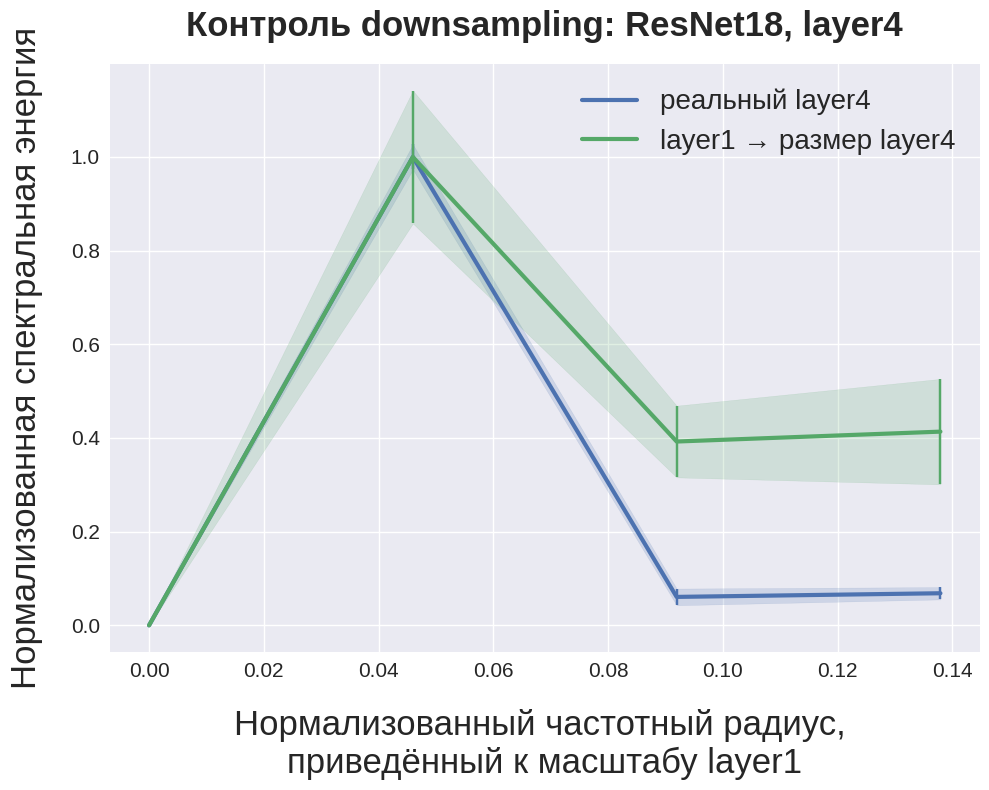

In [9]:
# Основной контроль делаем на ResNet18 как на базовой модели.
base_model = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE)
model = HookedResNet(base_model).to(DEVICE)

resnet_control = collect_downsampling_control(
    model=model,
    loader=val_loader,
    device=DEVICE,
    source_layer="layer1",
    target_layers=["layer2", "layer3", "layer4"],
    max_batches=MAX_BATCHES,
    mode="avg_pool"
)

ref_len = len(all_resnet_stats["ResNet_18"]["layer1"]["rho"])
resnet_control_table = control_metrics_table(
    resnet_control,
    source_layer="layer1",
    target_layers=["layer2", "layer3", "layer4"],
    ref_len=ref_len,
    mode="avg_pool",
    prefix="resnet18"
)
display(resnet_control_table.round(3))

plot_downsampling_control(resnet_control, "layer1", "layer4", ref_len, "ResNet18", save_path=os.path.join(FIG_PATH, "resnet18_downsampling_control_layer4.png"))

## Контрольный эксперимент ResNet: внутри одной стадии

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


saved: zero/spectra_npz/resnet50_layer3_blocks_control.npz


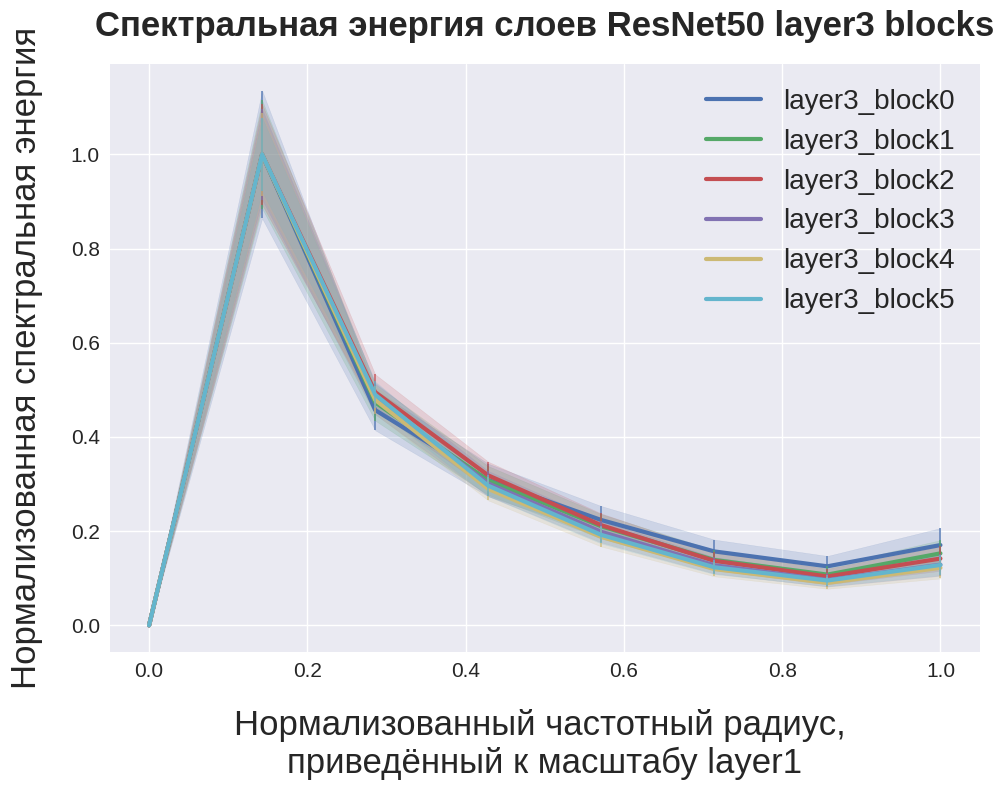

saved: zero/tables/resnet50_layer3_control_metrics_long.csv
saved: zero/tables/resnet50_layer3_control_metrics_latex_ready.csv
saved: zero/tables/resnet50_layer3_control_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ResNet50 layer3,Начальные,layer3_block0,0.463 $\pm$ 0.024,21.283 $\pm$ 4.059,43.225 $\pm$ 4.105
1,ResNet50 layer3,Средние,layer3_block3,0.439 $\pm$ 0.019,22.779 $\pm$ 3.116,38.352 $\pm$ 3.244
2,ResNet50 layer3,Глубокие,layer3_block5,0.436 $\pm$ 0.016,22.945 $\pm$ 2.554,37.711 $\pm$ 2.790


In [10]:
# Здесь проверяем изменение спектра внутри layer3 ResNet50, где spatial size не меняется.
base_model = resnet50(weights=ResNet50_Weights.DEFAULT).to(DEVICE)
model_blocks = HookedResNetBlocks(base_model, layer_name="layer3").to(DEVICE)
resnet50_layer3_stats = collect_all_spectra(model_blocks, val_loader, DEVICE, MAX_BATCHES)
save_spectra_npz(resnet50_layer3_stats, os.path.join(SPECTRA_PATH, "resnet50_layer3_blocks_control.npz"))

layer3_keys = list(resnet50_layer3_stats.keys())
plot_spectra_compare(
    "ResNet50 layer3 blocks",
    resnet50_layer3_stats,
    plot_layers=layer3_keys,
    ref_res=len(resnet50_layer3_stats[layer3_keys[0]]["mean"]),
    save_path=os.path.join(FIG_PATH, "resnet50_layer3_within_stage_control.png")
)

selected_blocks = {
    "Начальные": layer3_keys[0],
    "Средние": layer3_keys[len(layer3_keys)//2],
    "Глубокие": layer3_keys[-1],
}
within_metrics = compute_metrics_table(resnet50_layer3_stats, selected_blocks, ref_layer=layer3_keys[0], architecture="ResNet50_layer3")
within_latex = save_metrics_tables(within_metrics, "ResNet50 layer3", "resnet50_layer3_control")
display(within_latex)

## Загрузка уже сохранённых данных

In [11]:
# Пример, если эксперименты уже были посчитаны:
# stats_18 = load_spectra_npz(os.path.join(SPECTRA_PATH, "resnet18_all_layers.npz"))
# plot_spectra_compare("ResNet18", stats_18, plot_layers=["layer1", "layer2", "layer3", "layer4"])